# 1. Business understading

Data includes coordinates for drones.

Colums in dataset:
 - `clientid` - The unique identifier for the customer
 - `x` - The x coordinate of the customer's location, when plotted into a 2D plane
 - `y` - The y coordinate of the customer's location, when plotted into a 2D plane

The goal is to provide a model that can predict suitable drone hub locations based on customer locations. Unsupervised KMeans algorithm is the most suitable option for this problem

# 2. Data understanding

In [1]:
import pandas as pd
import time
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, accuracy_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("drone_cust_locations.csv", sep=";")

display(df.head())

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


In [3]:
df.dtypes

clientid      int64
x           float64
y           float64
dtype: object

## Data breakdown

Data includes only `clientid`, `x` and `y` coordinates.

# 3. Data preparation

It does not need or benefit from scaling.

Data is already a type `float64` -> do not need conversion.

We only need to separate coordinates `x` and `y` from data to a new dataframe called `X`, so it can be fed to the algorithm.

Lets separate the coordinates `x` and `y` to a new dataframe.

In [4]:
X = df[["x", "y"]]

In [5]:
X.isna().sum()

x    0
y    0
dtype: int64

## Data evaluation

There are no empty data in the given file -> no need for cleaning.

# 4. Modeling

First lets model with `KMeans` -algorithm.

In [6]:
# Same random state determines same results on every test in evaluation
random_state = 123

# K value was determined on 5. Evaluation -section
n_clusters = 3

kmeans_model = KMeans(init = "random", n_clusters = n_clusters, random_state = random_state)

Agglomerative clustering -model

In [7]:
agglomerative_model = AgglomerativeClustering(n_clusters=n_clusters)

# 5. Evaluation

For KMeans algorithm evaluation is best to use `elbow` -method to select `K` values for further evaluation

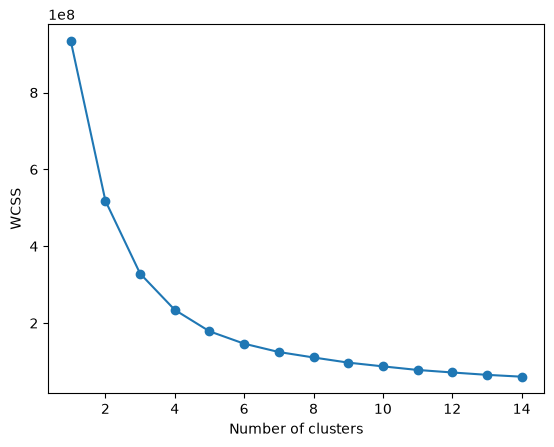

In [8]:
wcss_kmeans = []
for i in range(1,15):
    model = KMeans(init='random', n_clusters=i, random_state=random_state).fit(X)
    wcss_kmeans.append(model.inertia_)
    
plt.plot(range(1,15), wcss_kmeans, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Elbow method breakdown

WCSS seems to stabilize between `K` value of 3 to 6, but lets take deeper look including `2`, `7` and `8` values as well.

In [9]:
n_clusters_list = [2, 3, 4, 5, 6, 7, 8]

## Silhouette score

Let's compare above determined `K` values with silhouette score

In [10]:
for n_clusters in n_clusters_list:
    model = KMeans(init='random', n_clusters=n_clusters, random_state=random_state).fit(X)
    labels = model.labels_
    print(f'Silhouette score for k value of {n_clusters}: {silhouette_score(X, labels): .3f}')

Silhouette score for k value of 2:  0.423
Silhouette score for k value of 3:  0.423
Silhouette score for k value of 4:  0.403
Silhouette score for k value of 5:  0.418
Silhouette score for k value of 6:  0.399
Silhouette score for k value of 7:  0.388
Silhouette score for k value of 8:  0.389


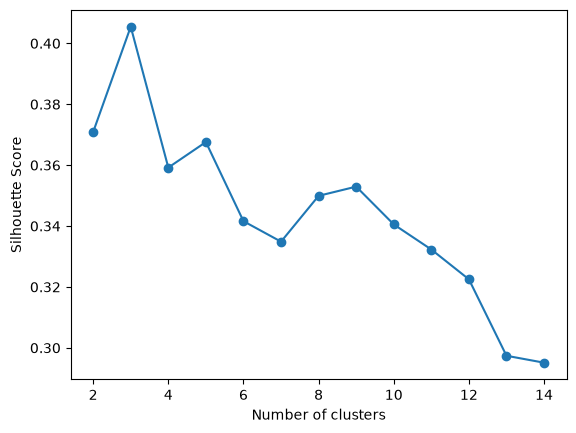

Silhouette score for numbers of clusters 2:  0.371
Silhouette score for numbers of clusters 3:  0.405
Silhouette score for numbers of clusters 4:  0.359
Silhouette score for numbers of clusters 5:  0.368
Silhouette score for numbers of clusters 6:  0.342
Silhouette score for numbers of clusters 7:  0.335
Silhouette score for numbers of clusters 8:  0.350
Silhouette score for numbers of clusters 9:  0.353
Silhouette score for numbers of clusters 10:  0.341
Silhouette score for numbers of clusters 11:  0.332
Silhouette score for numbers of clusters 12:  0.322
Silhouette score for numbers of clusters 13:  0.297
Silhouette score for numbers of clusters 14:  0.295


In [11]:
silhouette_scores = []

for i in range(2,15):
    model = AgglomerativeClustering(i)
    predict = model.fit_predict(X)

    silhouette_score_for_model = silhouette_score(X, predict)
    silhouette_scores.append(silhouette_score_for_model)

plt.plot(range(2,15), silhouette_scores, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

for i, score in enumerate(silhouette_scores):
    print(f"Silhouette score for numbers of clusters {i+2}: {score: .3f}")

## Visualize the depot stations in the cartasian coordinate system with **`3`**, **`4`**, **`5`** and **`6`**.

### KMeans

2 depots took  0.018 seconds to be completed


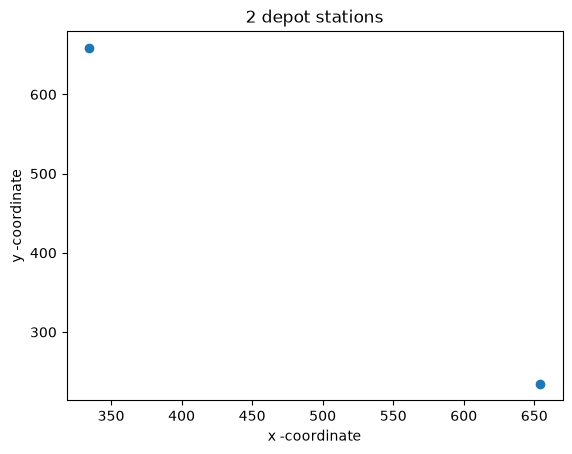

3 depots took  0.028 seconds to be completed


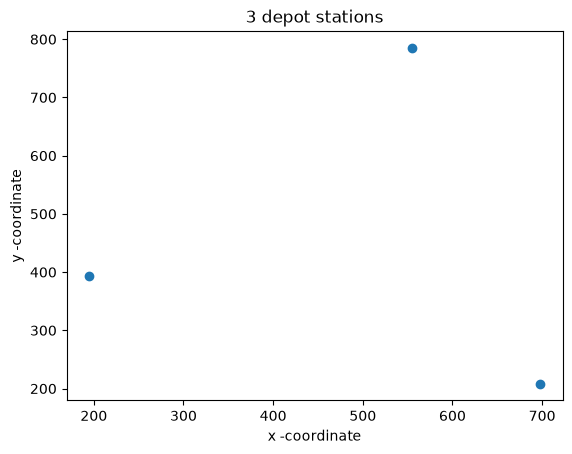

4 depots took  0.033 seconds to be completed


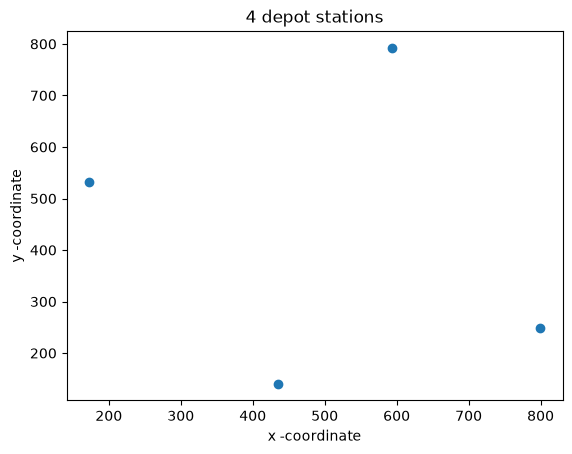

5 depots took  0.030 seconds to be completed


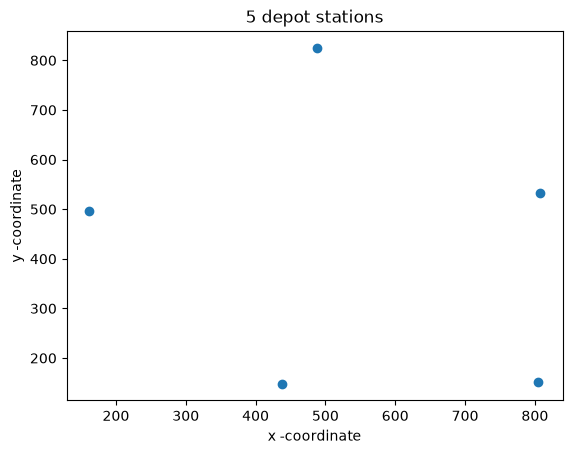

6 depots took  0.048 seconds to be completed


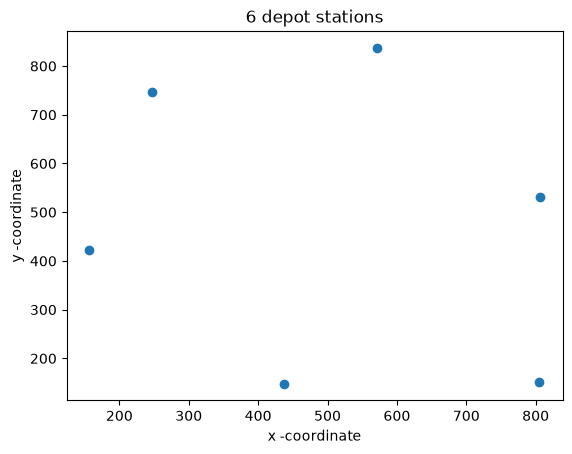

In [12]:
depot_list = [2, 3, 4, 5, 6]

for depots in depot_list:
    start_time = time.time()
    model = KMeans(init='random', n_clusters=depots, random_state=random_state)
    model.fit(X)
    
    centers = model.cluster_centers_
    end_time = time.time()
    duration = end_time - start_time
    print(f'{depots} depots took {duration: .3f} seconds to be completed')
    plt.plot(centers[:, 0], centers[:, 1], 'o')
    plt.title(f"{depots} depot stations")
    plt.xlabel("x -coordinate")
    plt.ylabel("y -coordinate")
    plt.show()

### Agglomerative clusterring

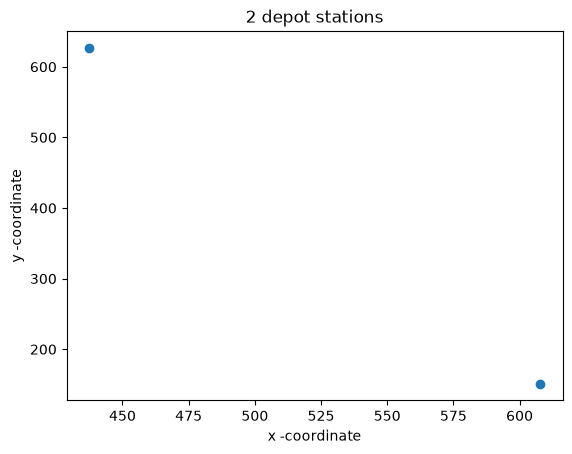

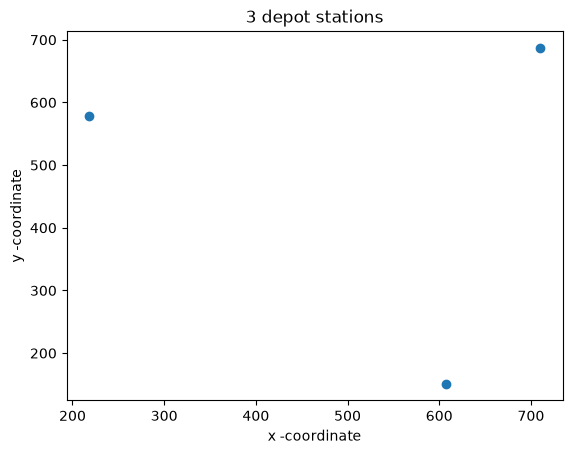

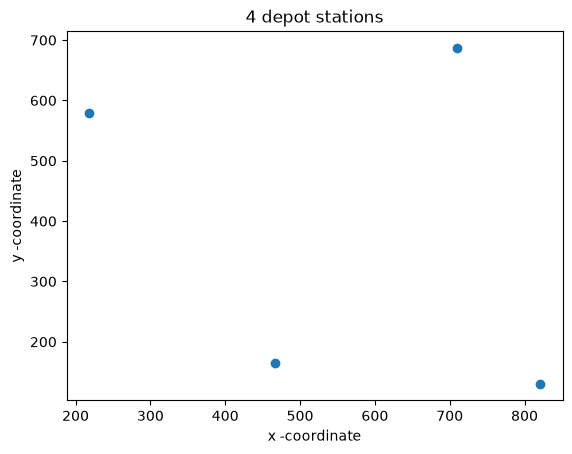

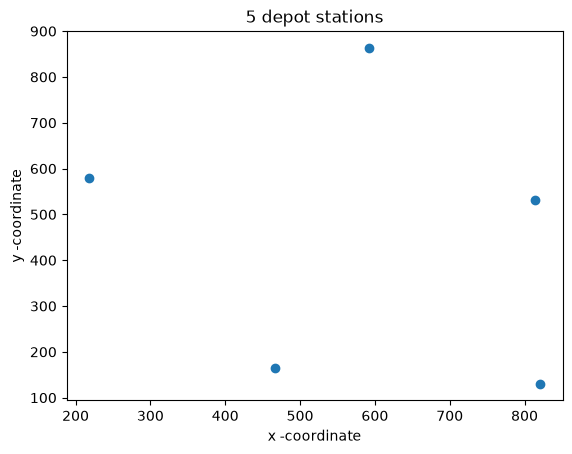

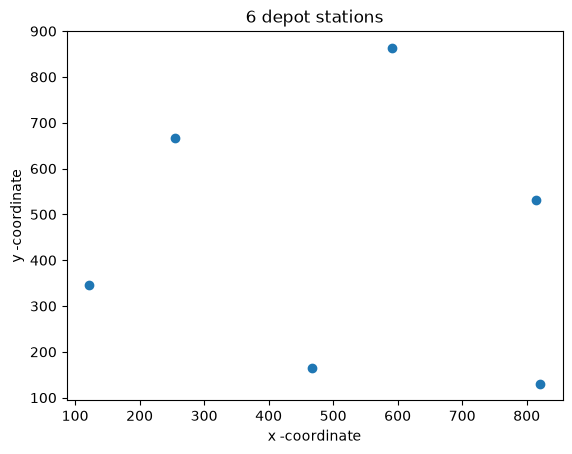

In [13]:
for depots in depot_list:
    model = AgglomerativeClustering(depots)

    predict = model.fit_predict(X)

    temp = X.copy()
    temp["cluster"] = predict

    # calculating the depot stations place in the coordinate
    centers = temp.groupby("cluster")[["x", "y"]].mean()
    
    plt.plot(centers["x"], centers["y"], 'o')
    plt.title(f"{depots} depot stations")
    plt.xlabel("x -coordinate")
    plt.ylabel("y -coordinate")
    plt.show()

## Depot stations conclusion

As seen plots above number of **`3`** for depotstations seems not to vary from even **`6`** depot stations. This indicates **`3`** depot stations will be sufficient amount and optimal number for the company. 

## Evaluation conclusion

### KMeans
As seen on `Elbow` method the `K` value should be in between 3 to 6. With `Silhouette score` the `K` value should be either `2`, `3` or `5` as all of them is around 0.42. `K` value of **`3`** seems to be the best option with both evaluation methods. The score `0.423` is not great, but it is the best score we get as we see it to get lower with bigger `K` values. Either way `silhouette score` `0.423` means that many of the clusters overlap some what each other. Its not bad, but higher value would provide better confidence to the algorithm.

### Agglomerative clustering
Plotting indicates optimal `K`value to be **`3`**. It comes with silhouette_score **`0.405`** when the nearest are `K`value of **`2`**: **`0.371`** and `K`value of 4: **`0.359`**

# 6. Deployment

`KMeans` algorithm might not suit the best for this data due low `silhouette score` `0.423`. It is not the worst, because it is in 0.4 to 0.45 -range, which conclude reasonable clustering structure.

`Agglomerative clustering`gives lower `silhouete score` of **`0.405`** against `KMeans`**`0.423`** with same `K` values of **`3`**.